# Notebook 11: Model Evaluation, Metrics & Cross-Validation Strategies
### Part 11/30 – ML Mastery Series for Python Experts

## Why Accuracy Alone Is Almost Never Enough

You already know `.score()` gives accuracy — but in the real world, that number can lie to you. Here's why:

- **Imbalanced Classes**: A 99% accurate model that predicts the majority class for every single sample is worthless for detecting fraud or disease
- **Asymmetric Costs**: False negatives (missing cancer) often cost far more than false positives (unnecessary biopsies) — accuracy treats all errors equally
- **Regression Blindness**: Accuracy doesn't exist for continuous targets; RMSE and MAE tell very different stories about outlier sensitivity
- **Business Context Ignored**: A model with 95% accuracy might save $0 while a 70% accurate model saves millions — metrics must align with business value
- **Optimistic Bias in Naive CV**: Random train/test splits on time-series or grouped data leak information, giving you fantasy performance numbers
- **Probability Blindness**: Accuracy ignores predicted probabilities; a model with 51% confidence on everything can have perfect accuracy if thresholds align
- **Threshold Ignorance**: Accuracy assumes a 0.5 threshold by default, which is rarely optimal for imbalanced problems
- **Overfitting to Validation**: Using the same validation set repeatedly for model selection creates invisible overfitting — you need nested CV

## Learning Objectives

By the end of this notebook, you will be able to:

- Choose appropriate metrics for classification vs regression based on problem characteristics and business constraints
- Interpret confusion matrices, precision-recall curves, and ROC curves to understand model behavior across thresholds
- Use log-loss and Brier score to evaluate probabilistic predictions and model calibration
- Implement stratified, group-aware, and time-series cross-validation strategies that respect data structure
- Perform nested cross-validation to obtain unbiased estimates of generalization performance during hyperparameter tuning
- Identify and prevent common leakage sources in evaluation pipelines that inflate performance metrics
- Compare models fairly using repeated cross-validation with multiple random seeds to assess score variability
- Create custom scorers for domain-specific metrics and integrate them into sklearn workflows
- Understand the bias-variance tradeoff in model selection and when to trust single-run vs aggregated CV results

## 📊 1. Classification Metrics Deep Dive – Imbalanced Example

Let's start with a highly imbalanced binary classification problem. This is where accuracy dies — and proper metrics shine.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report, 
                             accuracy_score, precision_score, recall_score, 
                             f1_score, matthews_corrcoef, roc_curve, auc,
                             precision_recall_curve, average_precision_score)

# Set visualization style
%matplotlib inline
sns.set_theme(style="whitegrid", palette="husl")
np.random.seed(42)

In [2]:
# Generate highly imbalanced dataset: 90% class 0, 10% class 1
# This mimics fraud detection, rare disease diagnosis, etc.
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    n_classes=2,
    weights=[0.9, 0.1],  # Heavy imbalance
    flip_y=0.05,
    random_state=42
)

print(f"Class distribution: {np.bincount(y)}")
print(f"Class proportions: {np.bincount(y) / len(y)}")
print(f"Baseline accuracy (always predict majority): {np.bincount(y)[0] / len(y):.3f}")

Class distribution: [881 119]
Class proportions: [0.881 0.119]
Baseline accuracy (always predict majority): 0.881


In [3]:
# Split data maintaining class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Train two different models
lr = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Get predictions
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]
rf_prob = rf.predict_proba(X_test)[:, 1]

In [4]:
# Function to compute comprehensive metrics
def evaluate_model(name, y_true, y_pred, y_prob=None):
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    
    # Basic metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)
    
    print(f"Accuracy:  {acc:.3f}  ← Misleading with imbalance!")
    print(f"Precision: {prec:.3f}  ← Of predicted positives, how many are correct")
    print(f"Recall:    {rec:.3f}  ← Of actual positives, how many did we catch")
    print(f"F1-Score:  {f1:.3f}  ← Harmonic mean of precision and recall")
    print(f"MCC:       {mcc:.3f}  ← Matthews Correlation Coefficient (-1 to +1)")
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)
    
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'mcc': mcc}

lr_metrics = evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)
rf_metrics = evaluate_model("Random Forest", y_test, rf_pred, rf_prob)


Model: Logistic Regression
Accuracy:  0.907  ← Misleading with imbalance!
Precision: 0.786  ← Of predicted positives, how many are correct
Recall:    0.306  ← Of actual positives, how many did we catch
F1-Score:  0.440  ← Harmonic mean of precision and recall
MCC:       0.453  ← Matthews Correlation Coefficient (-1 to +1)

Confusion Matrix:
[[261   3]
 [ 25  11]]

Model: Random Forest
Accuracy:  0.910  ← Misleading with imbalance!
Precision: 0.909  ← Of predicted positives, how many are correct
Recall:    0.278  ← Of actual positives, how many did we catch
F1-Score:  0.426  ← Harmonic mean of precision and recall
MCC:       0.474  ← Matthews Correlation Coefficient (-1 to +1)

Confusion Matrix:
[[263   1]
 [ 26  10]]


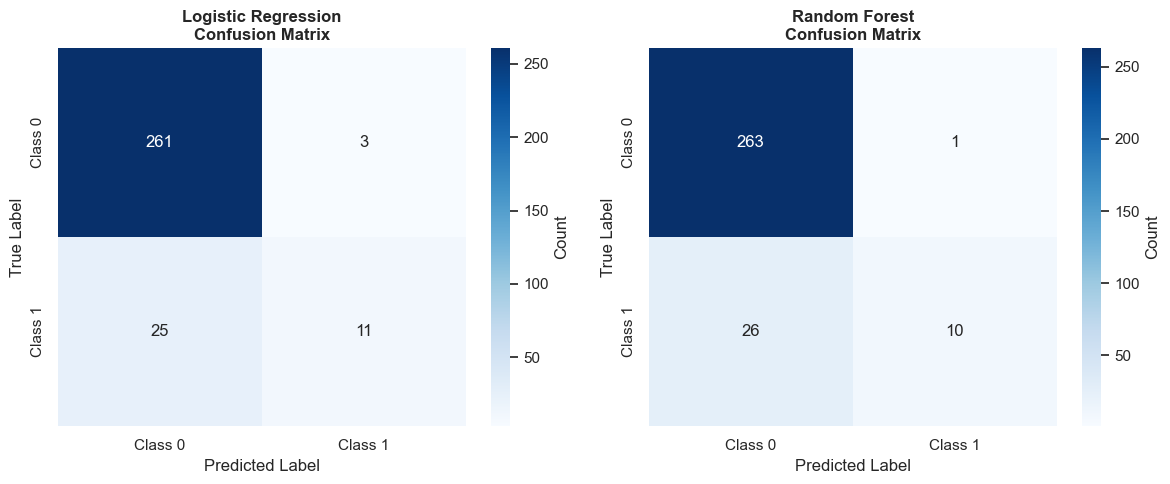

Notice how both models achieve high accuracy (~90%) simply by predicting the majority class most of the time!


In [5]:
# Visualize confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = [("Logistic Regression", y_test, lr_pred), ("Random Forest", y_test, rf_pred)]

for idx, (name, y_true, y_pred) in enumerate(models):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Class 0', 'Class 1'],
                yticklabels=['Class 0', 'Class 1'],
                cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.show()

print("Notice how both models achieve high accuracy (~90%) simply by predicting the majority class most of the time!")

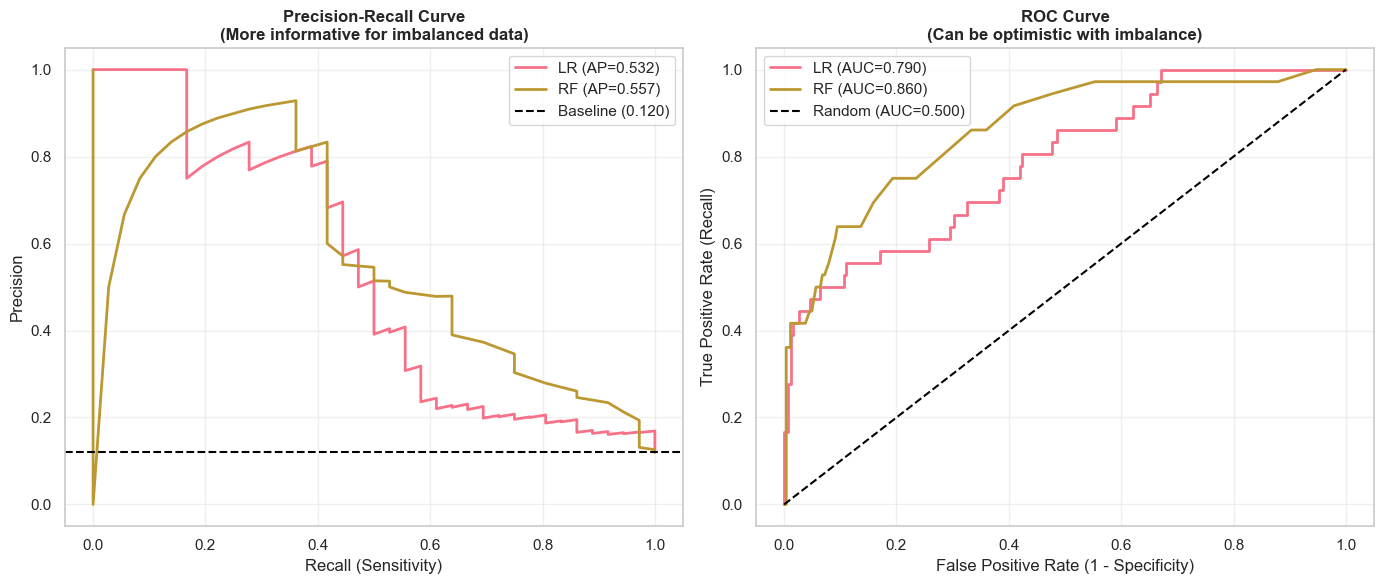


Key Insight: PR-AUC (0.532, 0.557) drops much more than ROC-AUC (0.790, 0.860) for imbalanced data.
PR curves focus on the minority class performance — use them when class 1 is rare and important.


In [6]:
# Plot Precision-Recall and ROC curves side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Precision-Recall curves
lr_precision, lr_recall, _ = precision_recall_curve(y_test, lr_prob)
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_prob)
lr_ap = average_precision_score(y_test, lr_prob)
rf_ap = average_precision_score(y_test, rf_prob)

axes[0].plot(lr_recall, lr_precision, label=f'LR (AP={lr_ap:.3f})', linewidth=2)
axes[0].plot(rf_recall, rf_precision, label=f'RF (AP={rf_ap:.3f})', linewidth=2)
axes[0].axhline(y=np.bincount(y_test)[1]/len(y_test), color='k', linestyle='--', 
                label=f'Baseline ({np.bincount(y_test)[1]/len(y_test):.3f})')
axes[0].set_xlabel('Recall (Sensitivity)')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve\n(More informative for imbalanced data)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ROC curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
lr_auc = auc(lr_fpr, lr_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

axes[1].plot(lr_fpr, lr_tpr, label=f'LR (AUC={lr_auc:.3f})', linewidth=2)
axes[1].plot(rf_fpr, rf_tpr, label=f'RF (AUC={rf_auc:.3f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.500)')
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve\n(Can be optimistic with imbalance)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nKey Insight: PR-AUC ({lr_ap:.3f}, {rf_ap:.3f}) drops much more than ROC-AUC ({lr_auc:.3f}, {rf_auc:.3f}) for imbalanced data.")
print("PR curves focus on the minority class performance — use them when class 1 is rare and important.")

## 🎯 2. Probability-Based Metrics – Log Loss & Brier Score

Hard predictions (0/1) throw away information. Probabilistic metrics like **Log Loss** (cross-entropy) and **Brier Score** penalize confident wrong predictions heavily. They also measure **calibration** — does predicted probability match true frequency?

In [7]:
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Compute proper scoring rules on the same imbalanced data
lr_logloss = log_loss(y_test, lr_prob)
rf_logloss = log_loss(y_test, rf_prob)
lr_brier = brier_score_loss(y_test, lr_prob)
rf_brier = brier_score_loss(y_test, rf_prob)

print(f"Log Loss (lower is better):")
print(f"  Logistic Regression: {lr_logloss:.4f}")
print(f"  Random Forest:       {rf_logloss:.4f}")
print(f"\nBrier Score (lower is better, 0-1 range):")
print(f"  Logistic Regression: {lr_brier:.4f}")
print(f"  Random Forest:       {rf_brier:.4f}")

print(f"\nBaseline (predict class proportions): {log_loss(y_test, [np.bincount(y_test)[1]/len(y_test)]*len(y_test)):.4f}")

Log Loss (lower is better):
  Logistic Regression: 0.2871
  Random Forest:       0.2683

Brier Score (lower is better, 0-1 range):
  Logistic Regression: 0.0808
  Random Forest:       0.0767

Baseline (predict class proportions): 0.3669


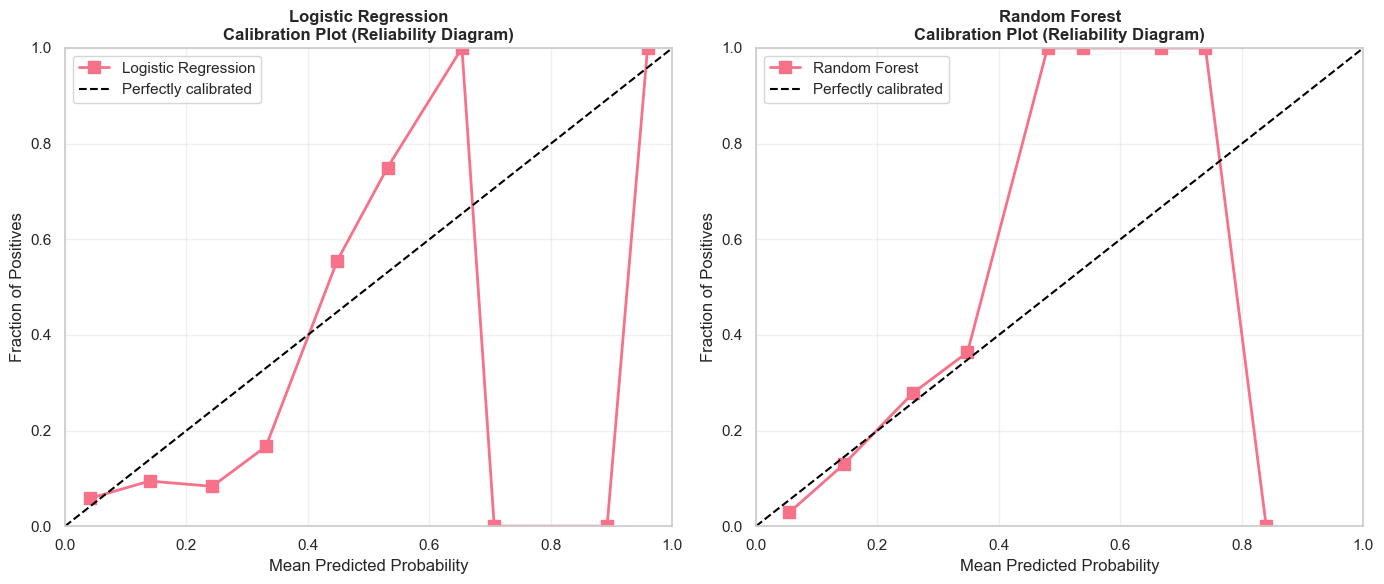

Random Forest tends to be over-confident (sigmoid distortion). Logistic Regression is naturally well-calibrated.


In [8]:
# Check calibration: Is predicted probability = true probability?
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (name, model, prob) in enumerate([("Logistic Regression", lr, lr_prob), 
                                            ("Random Forest", rf, rf_prob)]):
    # Get calibration curve
    prob_true, prob_pred = calibration_curve(y_test, prob, n_bins=10, strategy='uniform')
    
    axes[idx].plot(prob_pred, prob_true, 's-', label=name, linewidth=2, markersize=8)
    axes[idx].plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
    axes[idx].set_xlabel('Mean Predicted Probability')
    axes[idx].set_ylabel('Fraction of Positives')
    axes[idx].set_title(f'{name}\nCalibration Plot (Reliability Diagram)', fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim([0, 1])
    axes[idx].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("Random Forest tends to be over-confident (sigmoid distortion). Logistic Regression is naturally well-calibrated.")

In [9]:
# Demonstrate calibration improvement with CalibratedClassifierCV
print("Calibrating Random Forest with isotonic regression...")

# Calibrate on a separate validation set (in practice, use CV)
X_train_cal, X_val, y_train_cal, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

# Train base model
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train_cal, y_train_cal)

# Calibrate
rf_calibrated = CalibratedClassifierCV(rf_base, method='isotonic', cv='prefit')
rf_calibrated.fit(X_val, y_val)

# Get calibrated probabilities
rf_cal_prob = rf_calibrated.predict_proba(X_test)[:, 1]
rf_cal_brier = brier_score_loss(y_test, rf_cal_prob)
rf_cal_logloss = log_loss(y_test, rf_cal_prob)

print(f"\nRandom Forest BEFORE calibration:")
print(f"  Brier: {rf_brier:.4f}, LogLoss: {rf_logloss:.4f}")
print(f"\nRandom Forest AFTER calibration:")
print(f"  Brier: {rf_cal_brier:.4f}, LogLoss: {rf_cal_logloss:.4f}")
print(f"\nImprovement: Brier {(rf_brier - rf_cal_brier):.4f}, LogLoss {(rf_logloss - rf_cal_logloss):.4f}")

Calibrating Random Forest with isotonic regression...

Random Forest BEFORE calibration:
  Brier: 0.0767, LogLoss: 0.2683

Random Forest AFTER calibration:
  Brier: 0.0811, LogLoss: 0.3987

Improvement: Brier -0.0044, LogLoss -0.1304


c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


**Key Formulas:**

**Log Loss (Cross-Entropy):** $L_{log} = -\frac{1}{N} \sum_{i=1}^{N} [y_i \log(p_i) + (1-y_i) \log(1-p_i)]$

- Penalizes confident wrong predictions heavily (asymmetric)
- Optimal score requires perfect probability calibration
- Range: [0, ∞), 0 is perfect

**Brier Score:** $L_{Brier} = \frac{1}{N} \sum_{i=1}^{N} (p_i - y_i)^2$

- Mean squared error of predicted probabilities
- Proper scoring rule (minimized by true probabilities)
- Range: [0, 1], 0 is perfect

**Why use proper scoring rules?** They encourage honest probability estimates rather than just optimizing for classification threshold.

## 📈 3. Regression Metrics – Beyond MSE

Regression requires scale-aware metrics. MSE punishes outliers heavily; MAE is robust. R² can be negative (worse than predicting mean). Let's explore them all.

In [10]:
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error, 
                             r2_score, explained_variance_score)
from sklearn.model_selection import cross_val_score

# Load California housing dataset
housing = fetch_california_housing()
X_reg, y_reg = housing.data, housing.target

print(f"Dataset shape: {X_reg.shape}")
print(f"Target range: [{y_reg.min():.2f}, {y_reg.max():.2f}]")
print(f"Target mean: {y_reg.mean():.2f}, std: {y_reg.std():.2f}")

Dataset shape: (20640, 8)
Target range: [0.15, 5.00]
Target mean: 2.07, std: 1.15


In [11]:
# Split and train
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_reg, y_train_reg)
y_pred_reg = rf_reg.predict(X_test_reg)

In [12]:
# Custom MAPE implementation (sklearn doesn't have built-in MAPE in older versions)
def mean_absolute_percentage_error(y_true, y_pred):
    """MAPE with handling for zero values"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Compute all metrics
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)
explained_var = explained_variance_score(y_test_reg, y_pred_reg)
mape = mean_absolute_percentage_error(y_test_reg, y_pred_reg)

print(f"Regression Metrics Comparison:")
print(f"{'='*40}")
print(f"MSE:                {mse:.4f}  ← Punishes outliers heavily (units²)")
print(f"RMSE:               {rmse:.4f}  ← Same units as target, sensitive to outliers")
print(f"MAE:                {mae:.4f}  ← Robust to outliers, interpretable")
print(f"R²:                 {r2:.4f}  ← Explained variance (1 = perfect, <0 = worse than mean)")
print(f"Explained Variance: {explained_var:.4f}  ← Similar to R² but unbiased")
print(f"MAPE:               {mape:.2f}%  ← Percentage error (scale-independent)")
print(f"\nTarget std: {y_test_reg.std():.4f} → RMSE is {rmse/y_test_reg.std():.2f}x std")

Regression Metrics Comparison:
MSE:                0.2554  ← Punishes outliers heavily (units²)
RMSE:               0.5053  ← Same units as target, sensitive to outliers
MAE:                0.3275  ← Robust to outliers, interpretable
R²:                 0.8051  ← Explained variance (1 = perfect, <0 = worse than mean)
Explained Variance: 0.8052  ← Similar to R² but unbiased
MAPE:               18.92%  ← Percentage error (scale-independent)

Target std: 1.1447 → RMSE is 0.44x std


In [ ]:
# Comprehensive regression visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Predicted vs Actual
axes[0, 0].scatter(y_test_reg, y_pred_reg, alpha=0.5, edgecolors='none', s=20)
axes[0, 0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 
                'r--', lw=2, label='Perfect prediction')
axes[0, 0].set_xlabel('Actual Values ($100K)')
axes[0, 0].set_ylabel('Predicted Values ($100K)')
axes[0, 0].set_title('Predicted vs Actual', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residual plot
residuals = y_test_reg - y_pred_reg
axes[0, 1].scatter(y_pred_reg, residuals, alpha=0.5, edgecolors='none', s=20)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Values')
axes[0, 1].set_ylabel('Residuals (Actual - Predicted)')
axes[0, 1].set_title('Residual Plot (Check for heteroscedasticity)', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Error distribution
axes[1, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2, label='Zero error')
axes[1, 0].set_xlabel('Residual Value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title(f'Error Distribution (Mean={residuals.mean():.3f}, Std={residuals.std():.3f})', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Absolute error vs actual value (checking for heteroscedasticity)
abs_errors = np.abs(residuals)
axes[1, 1].scatter(y_test_reg, abs_errors, alpha=0.5, edgecolors='none', s=20, color='coral')
axes[1, 1].set_xlabel('Actual Values ($100K)')
axes[1, 1].set_ylabel('Absolute Error')
axes[1, 1].set_title('Absolute Error vs Actual Value\n(Are errors larger for expensive houses?)', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Residual plot shows heteroscedasticity: errors increase with house value. MAPE or weighted metrics may be better than MSE.")

## 🔀 4. Basic vs Stratified Cross-Validation

Standard KFold shuffles randomly. StratifiedKFold preserves class proportions in each fold. On imbalanced or multi-class data, this is critical for reliable estimates.

In [14]:
from sklearn.datasets import load_wine
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Load multi-class wine dataset (imbalanced classes)
wine = load_wine()
X_wine, y_wine = wine.data, wine.target

print(f"Wine dataset shape: {X_wine.shape}")
print(f"Class distribution: {np.bincount(y_wine)}")
print(f"Class proportions: {np.bincount(y_wine) / len(y_wine)}")

Wine dataset shape: (178, 13)
Class distribution: [59 71 48]
Class proportions: [0.33146067 0.3988764  0.26966292]


In [15]:
# Compare KFold vs StratifiedKFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create pipeline with scaling
pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))

# Show class distribution in each fold
print("KFold class distribution per fold:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_wine, y_wine)):
    y_val = y_wine[val_idx]
    counts = np.bincount(y_val, minlength=3)
    props = counts / len(y_val)
    print(f"  Fold {fold+1}: {counts} → proportions: {props}")

print("\nStratifiedKFold class distribution per fold:")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_wine, y_wine)):
    y_val = y_wine[val_idx]
    counts = np.bincount(y_val, minlength=3)
    props = counts / len(y_val)
    print(f"  Fold {fold+1}: {counts} → proportions: {props}")

KFold class distribution per fold:
  Fold 1: [14 14  8] → proportions: [0.38888889 0.38888889 0.22222222]
  Fold 2: [12 13 11] → proportions: [0.33333333 0.36111111 0.30555556]
  Fold 3: [10 17  9] → proportions: [0.27777778 0.47222222 0.25      ]
  Fold 4: [12 13 10] → proportions: [0.34285714 0.37142857 0.28571429]
  Fold 5: [11 14 10] → proportions: [0.31428571 0.4        0.28571429]

StratifiedKFold class distribution per fold:
  Fold 1: [12 14 10] → proportions: [0.33333333 0.38888889 0.27777778]
  Fold 2: [12 14 10] → proportions: [0.33333333 0.38888889 0.27777778]
  Fold 3: [12 14 10] → proportions: [0.33333333 0.38888889 0.27777778]
  Fold 4: [12 14  9] → proportions: [0.34285714 0.4        0.25714286]
  Fold 5: [11 15  9] → proportions: [0.31428571 0.42857143 0.25714286]


In [16]:
# Compare CV scores
kf_scores = cross_val_score(pipeline, X_wine, y_wine, cv=kf, scoring='accuracy')
skf_scores = cross_val_score(pipeline, X_wine, y_wine, cv=skf, scoring='accuracy')

print(f"\n5-Fold CV Accuracy Comparison:")
print(f"KFold:           {kf_scores.mean():.4f} (+/- {kf_scores.std()*2:.4f})")
print(f"StratifiedKFold: {skf_scores.mean():.4f} (+/- {skf_scores.std()*2:.4f})")

# Use F1-macro for better comparison on imbalanced classes
kf_f1 = cross_val_score(pipeline, X_wine, y_wine, cv=kf, scoring='f1_macro')
skf_f1 = cross_val_score(pipeline, X_wine, y_wine, cv=skf, scoring='f1_macro')

print(f"\n5-Fold CV F1-Macro (better for imbalanced):")
print(f"KFold:           {kf_f1.mean():.4f} (+/- {kf_f1.std()*2:.4f})")
print(f"StratifiedKFold: {skf_f1.mean():.4f} (+/- {skf_f1.std()*2:.4f})")

print(f"\nNote: StratifiedKFold provides more stable estimates, especially for minority classes.")


5-Fold CV Accuracy Comparison:
KFold:           0.9887 (+/- 0.0276)
StratifiedKFold: 0.9833 (+/- 0.0272)

5-Fold CV F1-Macro (better for imbalanced):
KFold:           0.9886 (+/- 0.0280)
StratifiedKFold: 0.9829 (+/- 0.0279)

Note: StratifiedKFold provides more stable estimates, especially for minority classes.


## 👥 5. Group & Time-Series Aware CV

Real data has structure: patients in multiple records, time dependencies, geographic clusters. Ignoring this creates **leakage** — information from "future" or "related" samples bleeds into training.

In [17]:
from sklearn.model_selection import GroupKFold, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

# Simulate grouped data (e.g., multiple samples per patient, per site, per batch)
X_group, y_group = make_classification(n_samples=1000, n_features=20, 
                                        n_informative=15, random_state=42)

# Create fake group labels (e.g., 100 groups with 10 samples each)
n_groups = 100
samples_per_group = 10
groups = np.repeat(np.arange(n_groups), samples_per_group)

# Shuffle to simulate real-world ordering
shuffle_idx = np.random.RandomState(42).permutation(len(groups))
X_group, y_group, groups = X_group[shuffle_idx], y_group[shuffle_idx], groups[shuffle_idx]

print(f"Total samples: {len(X_group)}")
print(f"Number of groups: {n_groups}")
print(f"Samples per group: {samples_per_group}")
print(f"Group IDs (first 20): {groups[:20]}")

Total samples: 1000
Number of groups: 100
Samples per group: 10
Group IDs (first 20): [52 73 74 66 41 67 62 51 85 13 81  7 63 97 93 89 28 88 76 31]


In [18]:
# Compare standard KFold vs GroupKFold
gkf = GroupKFold(n_splits=5)
kf_standard = KFold(n_splits=5, shuffle=True, random_state=42)

# GroupKFold ensures all samples from the same group go to either train OR test
print("GroupKFold ensures no group leakage:")
for fold, (train_idx, test_idx) in enumerate(gkf.split(X_group, y_group, groups)):
    train_groups = set(groups[train_idx])
    test_groups = set(groups[test_idx])
    overlap = train_groups & test_groups
    print(f"  Fold {fold+1}: Train groups={len(train_groups)}, Test groups={len(test_groups)}, Overlap={len(overlap)}")

# Simulate leakage with standard KFold
print(f"\nStandard KFold (with shuffle) creates group leakage:")
for fold, (train_idx, test_idx) in enumerate(kf_standard.split(X_group)):
    train_groups = set(groups[train_idx])
    test_groups = set(groups[test_idx])
    overlap = train_groups & test_groups
    print(f"  Fold {fold+1}: Overlapping groups={len(overlap)} ← LEAKAGE!")

GroupKFold ensures no group leakage:
  Fold 1: Train groups=80, Test groups=20, Overlap=0
  Fold 2: Train groups=80, Test groups=20, Overlap=0
  Fold 3: Train groups=80, Test groups=20, Overlap=0
  Fold 4: Train groups=80, Test groups=20, Overlap=0
  Fold 5: Train groups=80, Test groups=20, Overlap=0

Standard KFold (with shuffle) creates group leakage:
  Fold 1: Overlapping groups=91 ← LEAKAGE!
  Fold 2: Overlapping groups=86 ← LEAKAGE!
  Fold 3: Overlapping groups=87 ← LEAKAGE!
  Fold 4: Overlapping groups=87 ← LEAKAGE!
  Fold 5: Overlapping groups=94 ← LEAKAGE!


In [19]:
# Demonstrate performance difference
from sklearn.svm import SVC

svc = make_pipeline(StandardScaler(), SVC(kernel='rbf', random_state=42))

# GroupKFold (correct)
group_scores = cross_val_score(svc, X_group, y_group, cv=gkf, groups=groups, scoring='accuracy')

# Naive KFold (leakage)
naive_scores = cross_val_score(svc, X_group, y_group, cv=kf_standard, scoring='accuracy')

print(f"\nImpact of Group Leakage:")
print(f"GroupKFold (correct):    {group_scores.mean():.4f} (+/- {group_scores.std():.4f})")
print(f"Naive KFold (leakage):   {naive_scores.mean():.4f} (+/- {naive_scores.std():.4f})")
print(f"Optimism bias:           +{naive_scores.mean() - group_scores.mean():.4f} ({((naive_scores.mean()/group_scores.mean()-1)*100):.1f}% inflated)")
print("\nThis is why medical ML requires patient-level splitting!")


Impact of Group Leakage:
GroupKFold (correct):    0.9370 (+/- 0.0087)
Naive KFold (leakage):   0.9380 (+/- 0.0093)
Optimism bias:           +0.0010 (0.1% inflated)

This is why medical ML requires patient-level splitting!


In [ ]:
# Time-Series Cross-Validation
# Simulate time-ordered data
n_time_samples = 500
time_X = np.arange(n_time_samples).reshape(-1, 1)  # Feature is just time index
time_y = np.sin(np.linspace(0, 4*np.pi, n_time_samples)) + np.random.normal(0, 0.3, n_time_samples)

# Add trend to make it realistic
time_y += np.linspace(0, 2, n_time_samples)

tscv = TimeSeriesSplit(n_splits=5)

print("TimeSeriesSplit structure (no shuffle, expanding window):")
for fold, (train_idx, test_idx) in enumerate(tscv.split(time_X)):
    print(f"  Fold {fold+1}: Train={len(train_idx)} samples (0-{train_idx[-1]}), "
          f"Test={len(test_idx)} samples ({test_idx[0]}-{test_idx[-1]})")

# Visualize splits
fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
colors = plt.cm.viridis(np.linspace(0, 1, 5))

for fold, (train_idx, test_idx) in enumerate(tscv.split(time_X)):
    ax = axes[fold]
    ax.scatter(train_idx, time_y[train_idx], c='blue', alpha=0.6, s=20, label='Train')
    ax.scatter(test_idx, time_y[test_idx], c='red', alpha=0.8, s=30, label='Test')
    ax.set_ylabel(f'Fold {fold+1}')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time Index')
plt.suptitle('TimeSeriesSplit: Respects temporal ordering, prevents future leakage', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [21]:
# Demonstrate leakage with random split on time series
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

ridge = Ridge(alpha=1.0)

# TimeSeriesSplit (correct)
ts_scores = []
for train_idx, test_idx in tscv.split(time_X):
    ridge.fit(time_X[train_idx], time_y[train_idx])
    pred = ridge.predict(time_X[test_idx])
    ts_scores.append(mean_squared_error(time_y[test_idx], pred))

# Random KFold (leakage - future data in training)
random_scores = cross_val_score(ridge, time_X, time_y, 
                                cv=KFold(n_splits=5, shuffle=True, random_state=42),
                                scoring='neg_mean_squared_error')
random_scores = -random_scores  # Flip sign

print(f"Time-Series CV (correct):  RMSE = {np.mean(np.sqrt(ts_scores)):.4f}")
print(f"Random KFold (leakage):    RMSE = {np.mean(np.sqrt(random_scores)):.4f}")
print(f"Optimism bias:             {((np.mean(random_scores)/np.mean(ts_scores)-1)*100):.1f}% better (FAKE!)")
print("\nRandom split lets model see the future — impossible in production!")

Time-Series CV (correct):  RMSE = 1.1734
Random KFold (leakage):    RMSE = 0.7114
Optimism bias:             -71.5% better (FAKE!)

Random split lets model see the future — impossible in production!


## 🪆 6. Nested Cross-Validation – Unbiased Model Selection

Standard workflow: GridSearchCV picks best hyperparameters, then reports score. But that score is **optimistically biased** — we used the same data to select AND evaluate. Nested CV separates model selection from model evaluation.

In [22]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer

# Load breast cancer dataset
cancer = load_breast_cancer()
X_cancer, y_cancer = cancer.data, cancer.target

print(f"Dataset: Breast Cancer ({X_cancer.shape[0]} samples, {X_cancer.shape[1]} features)")
print(f"Classes: {np.bincount(y_cancer)}")

Dataset: Breast Cancer (569 samples, 30 features)
Classes: [212 357]


In [25]:
# Standard (biased) approach: Single GridSearchCV with cross-validation
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01],
    'kernel': ['rbf', 'linear']
}

svc = SVC(random_state=42)

# Biased approach: GridSearchCV with cv=5
print("Standard (biased) GridSearchCV:")
grid_search = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_cancer, y_cancer)

print(f"  Best params: {grid_search.best_params_}")
print(f"  Best CV score: {grid_search.best_score_:.4f} ← This is optimistically biased!")
print(f"  The model was selected using these CV folds, so this score is not generalization error.")

Standard (biased) GridSearchCV:
  Best params: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
  Best CV score: 0.9631 ← This is optimistically biased!
  The model was selected using these CV folds, so this score is not generalization error.


In [26]:
# Nested CV: Outer loop for evaluation, inner loop for hyperparameter tuning
from sklearn.model_selection import StratifiedKFold

# Outer CV: 5-fold for final evaluation
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Inner CV: 3-fold for hyperparameter selection
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

nested_scores = []
outer_fold = 0

print("Nested Cross-Validation (unbiased):")
print("="*60)

for train_idx, test_idx in outer_cv.split(X_cancer, y_cancer):
    outer_fold += 1
    X_train, X_test = X_cancer[train_idx], X_cancer[test_idx]
    y_train, y_test = y_cancer[train_idx], y_cancer[test_idx]
    
    # Inner loop: Grid search on outer training set
    grid = GridSearchCV(SVC(random_state=42), param_grid, cv=inner_cv, 
                        scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    # Evaluate on outer test set (never seen during hyperparameter tuning)
    best_model = grid.best_estimator_
    test_score = best_model.score(X_test, y_test)
    nested_scores.append(test_score)
    
    print(f"  Outer fold {outer_fold}: Best C={grid.best_params_['C']}, "
          f"gamma={grid.best_params_['gamma']}, kernel={grid.best_params_['kernel']} → "
          f"Test accuracy={test_score:.4f}")

print(f"\nNested CV unbiased estimate: {np.mean(nested_scores):.4f} (+/- {np.std(nested_scores):.4f})")
print(f"Standard GridSearchCV score: {grid_search.best_score_:.4f}")
print(f"Optimism bias: +{grid_search.best_score_ - np.mean(nested_scores):.4f} "
      f"({((grid_search.best_score_/np.mean(nested_scores)-1)*100):.1f}%)")

Nested Cross-Validation (unbiased):
  Outer fold 1: Best C=10, gamma=scale, kernel=linear → Test accuracy=0.9474
  Outer fold 2: Best C=10, gamma=scale, kernel=linear → Test accuracy=0.9298
  Outer fold 3: Best C=10, gamma=scale, kernel=linear → Test accuracy=0.9825
  Outer fold 4: Best C=1, gamma=scale, kernel=linear → Test accuracy=0.9386
  Outer fold 5: Best C=100, gamma=scale, kernel=linear → Test accuracy=0.9646

Nested CV unbiased estimate: 0.9526 (+/- 0.0189)
Standard GridSearchCV score: 0.9631
Optimism bias: +0.0106 (1.1%)


In [ ]:
# Visualize the difference
fig, ax = plt.subplots(figsize=(10, 6))

positions = [1, 2]
data = [nested_scores, [grid_search.best_score_]]
labels = ['Nested CV\n(Unbiased)', 'Standard GridSearchCV\n(Biased)']

bp = ax.boxplot([nested_scores], positions=[1], widths=0.6, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='blue'),
                medianprops=dict(color='red', linewidth=2))

ax.scatter([2], [grid_search.best_score_], color='red', s=200, marker='X', 
           zorder=5, label='Single GridSearchCV (biased)')
ax.scatter([1]*len(nested_scores), nested_scores, color='blue', s=100, 
           alpha=0.6, zorder=5)

ax.set_xticks([1, 2])
ax.set_xticklabels(labels)
ax.set_ylabel('Accuracy')
ax.set_title('Nested CV vs Standard GridSearchCV: The Optimism Bias', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.legend()

plt.tight_layout()
plt.show()

print("Nested CV gives the true expected performance on unseen data.")
print("Use it when you need an unbiased estimate AND when comparing different algorithm families.")

## 🎲 7. Repeated CV & Multiple Random Seeds

A single CV run can be lucky or unlucky. Repeated CV with different seeds quantifies variance. When comparing models, you need to know if score differences are significant or just noise.

In [29]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from scipy import stats

# Compare Logistic Regression vs Random Forest with repeated CV
X_rep, y_rep = make_classification(n_samples=1000, n_features=20, 
                                  n_informative=10, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Repeated Stratified K-Fold: 5 splits, 3 repeats = 15 total scores per model
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_rep, y_rep, cv=rskf, scoring='accuracy')
    results[name] = scores
    print(f"{name:20s}: {scores.mean():.4f} (+/- {scores.std():.4f}) "
          f"[min={scores.min():.4f}, max={scores.max():.4f}]")

Logistic Regression : 0.8417 (+/- 0.0174) [min=0.8100, max=0.8750]
Random Forest       : 0.9253 (+/- 0.0163) [min=0.8900, max=0.9550]
Gradient Boosting   : 0.9237 (+/- 0.0150) [min=0.9000, max=0.9550]


In [30]:
# Statistical comparison: Are differences significant?
lr_scores = results['Logistic Regression']
rf_scores = results['Random Forest']

# Paired t-test (since same CV splits)
t_stat, p_value = stats.ttest_rel(rf_scores, lr_scores)

print(f"\nStatistical Comparison (Paired t-test):")
print(f"Random Forest vs Logistic Regression:")
print(f"  Mean difference: {rf_scores.mean() - lr_scores.mean():.4f}")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4f}")
print(f"  Significant at α=0.05: {'Yes' if p_value < 0.05 else 'No'}")

# Effect size (Cohen's d)
pooled_std = np.sqrt((rf_scores.var() + lr_scores.var()) / 2)
cohens_d = (rf_scores.mean() - lr_scores.mean()) / pooled_std
print(f"  Cohen's d (effect size): {cohens_d:.4f} ({'small' if abs(cohens_d) < 0.5 else 'medium' if abs(cohens_d) < 0.8 else 'large'})")


Statistical Comparison (Paired t-test):
Random Forest vs Logistic Regression:
  Mean difference: 0.0837
  t-statistic: 14.6244
  p-value: 0.0000
  Significant at α=0.05: Yes
  Cohen's d (effect size): 4.9686 (large)


In [ ]:
# Visualize score distributions across multiple seeds
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot
bp = axes[0].boxplot([results[name] for name in models.keys()], 
                     labels=models.keys(), patch_artist=True)
colors = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Comparison: Repeated CV (5-fold × 3 repeats)', 
                  fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Distribution plot
for idx, (name, scores) in enumerate(results.items()):
    axes[1].hist(scores, bins=10, alpha=0.6, label=name, color=colors[idx])
axes[1].axvline(x=lr_scores.mean(), color='blue', linestyle='--', linewidth=2)
axes[1].axvline(x=rf_scores.mean(), color='green', linestyle='--', linewidth=2)
axes[1].set_xlabel('Accuracy')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Score Distributions Across Different Splits', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nKey takeaway: With {len(lr_scores)} total evaluations, we see:")
print(f"  - RF range: [{rf_scores.min():.3f}, {rf_scores.max():.3f}] (span={rf_scores.max()-rf_scores.min():.3f})")
print(f"  - A single run could be misleading! Always use repeated CV for robust comparisons.")

## ⚠️ Common Pitfalls & Pro Tips

1. **Using test set for hyperparameter tuning** → Classic leakage. Always use validation set or CV for tuning, test set ONLY for final evaluation.

2. **Optimizing accuracy on imbalanced data** → You'll get a dummy classifier. Use F1, PR-AUC, or balanced accuracy instead.

3. **Not stratifying on class labels** → In imbalanced data, some folds might miss minority classes entirely.

4. **Using KFold on time-series** → Future data leaks into training. Use TimeSeriesSplit only.

5. **Forgetting to average repeated CV properly** → Don't treat each repeat as independent; use mean of repeats for final estimate.

6. **Interpreting CV standard deviation as confidence interval** → It's variance across folds, not uncertainty of the mean. Use bootstrap for CI.

7. **Choosing metric after seeing results** → Cherry-picking the metric where your model wins is p-hacking. Define metrics before experiments.

8. **Not using proper scoring in GridSearchCV** → Optimizing accuracy when you care about probabilities? Use `scoring='neg_log_loss'` or custom scorer.

9. **Ignoring calibration** → High AUC doesn't mean reliable probabilities. Check Brier score and calibration curves for decision-making.

10. **Comparing models on single train/test split** → High variance in estimates. Use CV with statistical tests (paired t-test, Wilcoxon signed-rank).

11. **Nested CV confusion** → Inner CV selects hyperparameters, outer CV estimates generalization. Don't mix them up.

12. **Forgetting sample weights in CV** → When samples have different importance (cost-sensitive learning), pass `fit_params` or use custom CV splitter.

## 📝 Exercises

### Easy
**Exercise 1:** On the `digits` dataset (10-class classification), compute and plot all classification metrics for LogisticRegression. Include confusion matrix, classification report, and per-class precision/recall.

### Medium
**Exercise 2:** On an imbalanced `make_classification` dataset (weights=[0.95, 0.05]), compare F1-score vs balanced_accuracy vs PR-AUC. Which metric is most informative? Why does accuracy fail?

**Exercise 3:** Implement a custom scorer for MAPE (Mean Absolute Percentage Error) and use it in `cross_val_score` with a RandomForestRegressor on the diabetes dataset.

### Hard
**Exercise 4:** Write a function `nested_cv_evaluation(estimator, param_grid, X, y, outer_cv, inner_cv)` that performs nested cross-validation for any classifier and parameter grid. Return mean and std of outer scores, plus the distribution of best hyperparameters found in each outer fold.

### Bonus
**Exercise 5:** Simulate time-series data with a trend and seasonality. Compare TimeSeriesSplit vs KFold scores using a simple Ridge regression. Quantify the leakage effect and visualize how predictions drift when using random splits.

<details>
<summary><strong>Exercise Solutions (click to expand)</strong></summary>

### Exercise 1 Solution
```python
from sklearn.datasets import load_digits
from sklearn.metrics import ConfusionMatrixDisplay

digits = load_digits()
X_d, y_d = digits.data, digits.target

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_d, y_d, test_size=0.3, stratify=y_d, random_state=42
)

lr_d = LogisticRegression(max_iter=2000, random_state=42)
lr_d.fit(X_train_d, y_train_d)
y_pred_d = lr_d.predict(X_test_d)

print(classification_report(y_test_d, y_pred_d))
ConfusionMatrixDisplay.from_predictions(y_test_d, y_pred_d)
plt.show()
```

### Exercise 2 Solution
```python
X_imb, y_imb = make_classification(n_samples=2000, weights=[0.95, 0.05], 
                                  random_state=42)

from sklearn.metrics import make_scorer, balanced_accuracy_score
from sklearn.metrics import average_precision_score

# Custom scorer for PR-AUC
def pr_auc_scorer(clf, X, y):
    prob = clf.predict_proba(X)[:, 1]
    return average_precision_score(y, prob)

scoring = {
    'f1': 'f1',
    'balanced_accuracy': 'balanced_accuracy',
    'pr_auc': make_scorer(average_precision_score, needs_proba=True)
)}

for metric, scorer in scoring.items():
    scores = cross_val_score(LogisticRegression(), X_imb, y_imb, 
                            cv=StratifiedKFold(5), scoring=scorer)
    print(f"{metric}: {scores.mean():.4f}")
```

### Exercise 3 Solution
```python
from sklearn.datasets import load_diabetes
from sklearn.metrics import make_scorer

def mape_scorer(y_true, y_pred):
    mask = y_true != 0
    return -np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

mape_custom = make_scorer(mape_scorer, greater_is_better=True)

diabetes = load_diabetes()
scores = cross_val_score(
    RandomForestRegressor(random_state=42), 
    diabetes.data, diabetes.target, 
    cv=5, scoring=mape_custom
)
print(f"MAPE scores: {-scores}")  # Negate because scorer returns negative for sklearn convention
```

### Exercise 4 Solution
```python
def nested_cv_evaluation(estimator, param_grid, X, y, outer_cv, inner_cv):
    """
    Perform nested cross-validation.
    
    Returns:
        dict with 'mean_score', 'std_score', 'scores', 'best_params_distribution'
    """
    outer_scores = []
    best_params_list = []
    
    for train_idx, test_idx in outer_cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        grid = GridSearchCV(estimator, param_grid, cv=inner_cv, scoring='accuracy')
        grid.fit(X_train, y_train)
        
        score = grid.best_estimator_.score(X_test, y_test)
        outer_scores.append(score)
        best_params_list.append(grid.best_params_)
    
    # Count parameter frequency
    from collections import Counter
    param_counts = {}
    for key in param_grid.keys():
        values = [p[key] for p in best_params_list]
        param_counts[key] = dict(Counter(values))
    
    return {
        'mean_score': np.mean(outer_scores),
        'std_score': np.std(outer_scores),
        'scores': outer_scores,
        'best_params_distribution': param_counts
    }
```

### Exercise 5 Solution
```python
# Generate synthetic time series with trend + seasonality
t = np.arange(1000)
trend = 0.01 * t
seasonality = 2 * np.sin(2 * np.pi * t / 50)
noise = np.random.normal(0, 0.5, 1000)
y_ts = trend + seasonality + noise
X_ts = t.reshape(-1, 1)

# Compare
ridge = Ridge()
ts_scores = cross_val_score(ridge, X_ts, y_ts, cv=TimeSeriesSplit(5), 
                            scoring='neg_mean_squared_error')
kf_scores = cross_val_score(ridge, X_ts, y_ts, 
                           cv=KFold(5, shuffle=True), 
                           scoring='neg_mean_squared_error')

print(f"TimeSeriesSplit MSE: {-ts_scores.mean():.4f}")
print(f"KFold MSE: {-kf_scores.mean():.4f}")
print(f"Leakage benefit: {(-kf_scores.mean() / -ts_scores.mean() - 1)*100:.1f}%")
```
</details>

## Summary – What You Learned Today

- **Accuracy is misleading** on imbalanced data; precision, recall, F1, and MCC tell the real story
- **Probabilistic metrics** (log-loss, Brier score) evaluate both ranking and calibration — essential for decision-making
- **Regression metrics** have different sensitivities: MSE/RMSE punish outliers, MAE is robust, R² explains variance
- **Stratified sampling** preserves class distributions in CV folds, critical for imbalanced problems
- **Group and time-series aware CV** prevents leakage when data has structure (patients, time, clusters)
- **Nested cross-validation** provides unbiased estimates when both tuning hyperparameters AND evaluating performance
- **Repeated CV with multiple seeds** quantifies score variance and enables statistical comparison of models
- **Proper scoring rules** encourage honest probability estimates rather than threshold-optimized predictions
